# BBC Articles Binary Classification: Sport vs Non-Sport

This notebook builds a **binary text classifier** using a Neural Network to distinguish between:
- `Sport`
- `Non-Sport`

The same dataset is split into **train**, **validation**, and **test** sets.

## 1. Setup

In [1]:

# !pip install pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load and Inspect the Dataset

In [2]:
DATA_PATH = 'bbc_articles.csv'
df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape}')
display(df.head(3))
print('\nClass distribution:')
print(df['category'].value_counts())

Dataset shape: (2000, 4)


,title,text,category,url
0,Norwich's Sargent completes move to Toronto,Josh Sargent scored 56 goals in 157 appearance...,sport,https://www.bbc.com/sport/football/articles/c9...
1,Arsenal's Smith out of Canada squad with concu...,Olivia Smith started Arsenal's FA Cup fifth-ro...,sport,https://www.bbc.com/sport/football/articles/cd...
2,Gordon needs to stay 'fully focused' after Ars...,Anthony Gordon has scored 14 goals for Newcast...,sport,https://www.bbc.com/sport/football/articles/cn...



Class distribution:
category
sport        1000
non-sport    1000
Name: count, dtype: int64


## 3. Binary Target and Text Preparation

In [3]:
# Keep only the categories required for the binary task
df = df[df['category'].isin(['sport', 'non-sport'])].copy()

# Binary label: sport -> 1, non-sport -> 0
label_map = {'non-sport': 0, 'sport': 1}
df['label'] = df['category'].map(label_map)

# Combine title + text for a richer input
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['combined_text'] = (df['title'] + ' ' + df['text']).str.strip()

print(df[['category', 'label']].head())
print('\nEmpty combined_text rows:', (df['combined_text'].str.len() == 0).sum())

  category  label
0    sport      1
1    sport      1
2    sport      1
3    sport      1
4    sport      1

Empty combined_text rows: 0


## 4. Train / Validation / Test Split

In [4]:
X = df['combined_text']
y = df['label']

# First split: Train+Val (80%) and Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Second split: Train (60% overall) and Validation (20% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f'Train size: {len(X_train)}')
print(f'Validation size: {len(X_val)}')
print(f'Test size: {len(X_test)}')

print('\nTrain class balance:')
print(y_train.value_counts(normalize=True))
print('\nValidation class balance:')
print(y_val.value_counts(normalize=True))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True))

Train size: 1200
Validation size: 400
Test size: 400

Train class balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation class balance:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test class balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 5. Text Vectorization (TF-IDF)

In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print('Train TF-IDF shape:', X_train_tfidf.shape)
print('Validation TF-IDF shape:', X_val_tfidf.shape)
print('Test TF-IDF shape:', X_test_tfidf.shape)

Train TF-IDF shape: (1200, 30000)
Validation TF-IDF shape: (400, 30000)
Test TF-IDF shape: (400, 30000)


## 6. Neural Network Training (MLP)

We train an `MLPClassifier` (feed-forward neural network) and monitor train/validation accuracy across epochs.

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE
)

EPOCHS = 20
train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    mlp.fit(X_train_tfidf, y_train)

    train_pred = mlp.predict(X_train_tfidf)
    val_pred = mlp.predict(X_val_tfidf)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch {epoch + 1:02d}/{EPOCHS} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')

/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 01/20 - Train Acc: 0.9925 - Val Acc: 0.9750


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 02/20 - Train Acc: 0.9975 - Val Acc: 0.9875


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 18/20 - Train Acc: 1.0000 - Val Acc: 0.9950


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 19/20 - Train Acc: 1.0000 - Val Acc: 0.9950
Epoch 20/20 - Train Acc: 1.0000 - Val Acc: 0.9950


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Best validation accuracy: 0.9950 at epoch 3


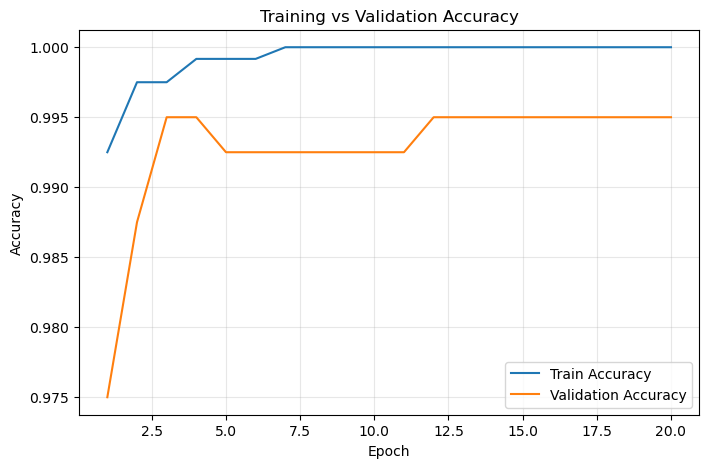

In [7]:
best_epoch = int(np.argmax(val_acc_history))
best_val_acc = val_acc_history[best_epoch]

print(f'Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch + 1}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluation on Test Set

In [8]:
y_test_pred = mlp.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='binary')

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall   : {recall:.4f}')
print(f'Test F1-score : {f1:.4f}')

print('\nDetailed classification report:')
print(classification_report(y_test, y_test_pred, target_names=['Non-Sport', 'Sport']))

Test Accuracy : 0.9925
Test Precision: 0.9852
Test Recall   : 1.0000
Test F1-score : 0.9926

Detailed classification report:
              precision    recall  f1-score   support

   Non-Sport       1.00      0.98      0.99       200
       Sport       0.99      1.00      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



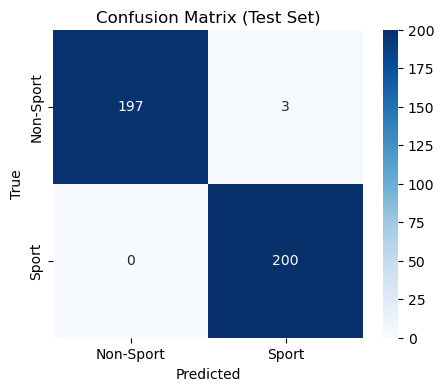

In [9]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Sport', 'Sport'],
    yticklabels=['Non-Sport', 'Sport']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()

## 8. Try New Examples

In [16]:
new_samples = [
    'Manchester United won 3-1 with a late goal in the Premier League.',
    'Bankrupt company announces restructuring plan.'
]

new_tfidf = vectorizer.transform(new_samples)
new_preds = mlp.predict(new_tfidf)
new_probs = mlp.predict_proba(new_tfidf)[:, 1]

for text, pred, prob in zip(new_samples, new_preds, new_probs):
    label = 'Sport' if pred == 1 else 'Non-Sport'
    print(f'Text: {text}')
    print(f'Predicted label: {label} (Sport probability={prob:.3f})')
    print('-' * 80)

Text: Manchester United won 3-1 with a late goal in the Premier League.
Predicted label: Sport (Sport probability=0.999)
--------------------------------------------------------------------------------
Text: Bankrupt company announces restructuring plan.
Predicted label: Non-Sport (Sport probability=0.199)
--------------------------------------------------------------------------------
